# Metody Monte Carlo - Laboratorium 1
### Miłosz Cieśla 325154

### Potrzebne importy

In [30]:
import numpy as np
import time
from matplotlib import pyplot as plt
import os

## Zadanie 1 - Liniowy generator kongruentny


### Generator

In [31]:
def generator(n, seed= 1, alpha = 17, c = 0):
    m = 2**13 - 1
    x = seed

    for i in range(1, n + 1):
        x = (alpha * x + c) % m
        yield x

### Zapis do pliku

In [32]:
def save_pairs_to_file(sequence, filename, step=1):
    with open(filename, 'w') as f:
        for i in range(len(sequence) - step):
            f.write(f"{sequence[i]} {sequence[i+step]}\n")

os.makedirs('./data', exist_ok=True)
os.makedirs('./plots', exist_ok=True)

seq_a17 = list(generator(2500, seed=1, alpha=17))
seq_a85 = list(generator(2500, seed=1, alpha=85))

save_pairs_to_file(seq_a17, './data/a17.txt')
save_pairs_to_file(seq_a85, './data/a85.txt')
save_pairs_to_file(seq_a17, './data/a17_step2.txt', step=2)
save_pairs_to_file(seq_a85, './data/a85_step2.txt', step=2)

### Kiedy uproszczenie C = 0 ma sens?
Poza polepszeniem wydajności wynikającym z pozbycia się dodatkowej operacji arytmetycznej, generatory multiplikatywne mają dobrze zbadane parametry alpha i m, które pozwalają na uzyskanie satysfakcjonującej losowości w prostych zastosowaniach. Należy jednak pamiętać, że uproszczenie to skraca maksymalny możliwy okres generatora do m - 1, co wymusza rygorystyczny dobór parametrów (np. m musi być liczbą pierwszą) i założenie, że wartość początkowa nigdy nie jest zerem.

### Struktura przestrzenna generatora - alpha = 17

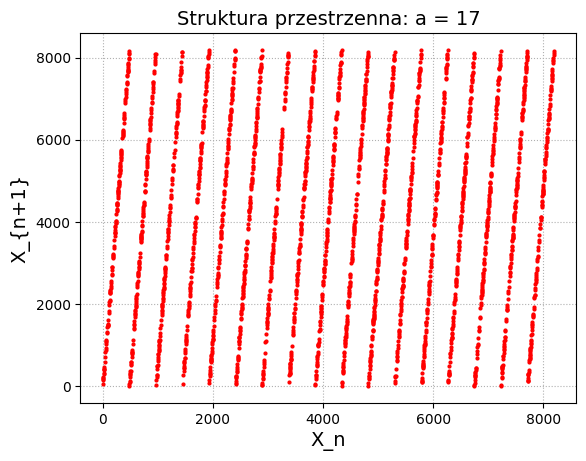

In [33]:
x_17, y_17 = np.loadtxt('./data/a17.txt', unpack=True)

plt.figure()
plt.plot(x_17, y_17, 'ro', markersize=2)
plt.title('Struktura przestrzenna: a = 17', fontsize=14)
plt.xlabel('X_n', fontsize=14)
plt.ylabel('X_{n+1}', fontsize=14)
plt.grid(linestyle=':')
plt.savefig('./plots/a17.pdf', format='pdf')
plt.show()

### Struktura przestrzenna - alpha = 85

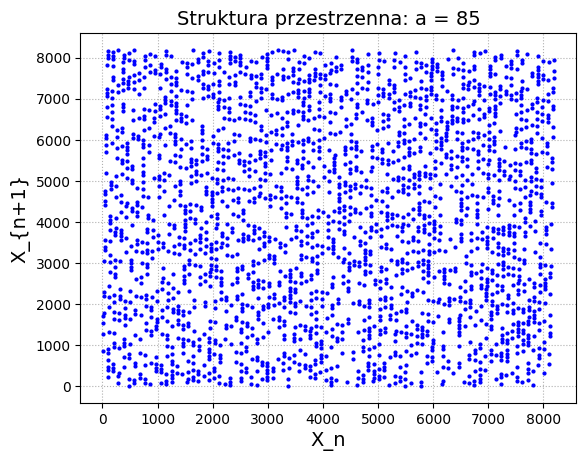

In [34]:
x_85, y_85 = np.loadtxt('./data/a85.txt', unpack=True)

plt.figure()
plt.plot(x_85, y_85, 'bo', markersize=2)
plt.title('Struktura przestrzenna: a = 85', fontsize=14)
plt.xlabel('X_n', fontsize=14)
plt.ylabel('X_{n+1}', fontsize=14)
plt.grid(linestyle=':')
plt.savefig('./plots/a85.pdf', format='pdf')
plt.show()

### Wnioski
Możemy zauważyć, że struktura przestrzenna drastycznie zmienia się w zależności od dobranej wartości alpha.
- Dla alpha = 17, punkty są skupione w niewielkiej liczbie oddalonych od siebie prostych, pozostawiając ogromne, puste przestrzenie. Oznacza to bardzo silną korelację i niską jakość pseudolosowości. Generator nie pokrywa całej dostępnej przestrzeni.
- Dla alpha = 85, siatka punktów jest znacznie gęstsza i równomierniej pokrywa całą dostępną dziedzinę. Znacznie mniejsze odległości między tworzącymi się "liniami" sprawiają, że rozkład przypomina losowy szum, co świadczy o wyższej jakości pseudolosowości. Wartość ta jest zatem zdecydowanie lepszym wyborem mnożnika dla danego modułu m.

### Struktura przestrzenna generatora - alpha = 17, krok = 2

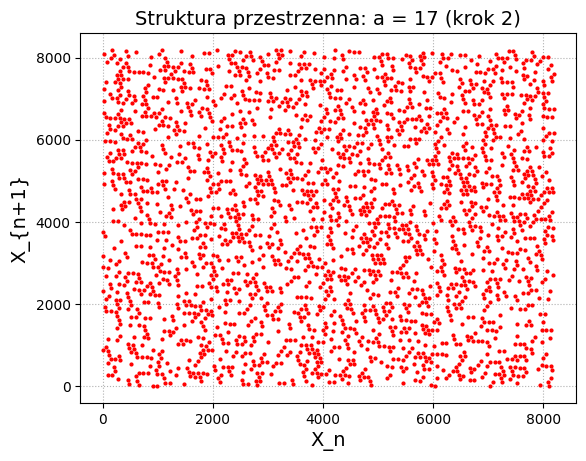

In [35]:
x_17, y_17 = np.loadtxt('./data/a17_step2.txt', unpack=True)

plt.figure()
plt.plot(x_17, y_17, 'ro', markersize=2)
plt.title('Struktura przestrzenna: a = 17 (krok 2)', fontsize=14)
plt.xlabel('X_n', fontsize=14)
plt.ylabel('X_{n+1}', fontsize=14)
plt.grid(linestyle=':')
plt.savefig('./plots/a17_step2.pdf', format='pdf')
plt.show()

### Struktura przestrzenna generatora - alpha = 85, krok = 2

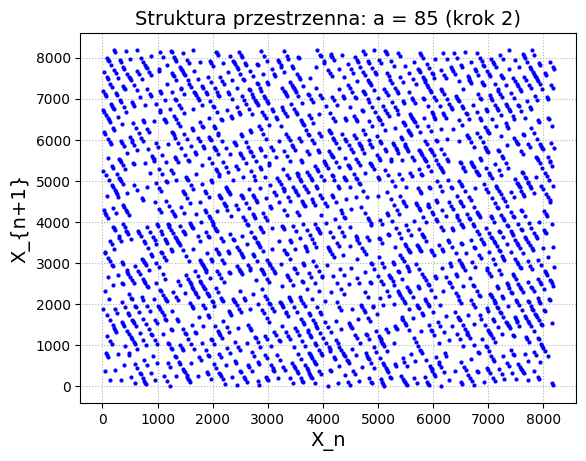

In [36]:
x_85, y_85 = np.loadtxt('./data/a85_step2.txt', unpack=True)

plt.figure()
plt.plot(x_85, y_85, 'bo', markersize=2)
plt.title('Struktura przestrzenna: a = 85 (krok 2)', fontsize=14)
plt.xlabel('X_n', fontsize=14)
plt.ylabel('X_{n+1}', fontsize=14)
plt.grid(linestyle=':')
plt.savefig('./plots/a85_step2.pdf', format='pdf')
plt.show()

### Wnioski
Analizujac struktury z krokiem równym 2 możemy wykryć ukryte wcześniej korelacje, między próbkami które nie są bezpośrednio po sobie. Przykładowo generator z alpha = 85, który przy analizie z krokiem 1 wydawał się znacznie lepszy i sprawiał wrażenie losowego szumu, obecnie ujawnia bardzo silną, ukrytą korelację. Wygenerowane punkty wyraźnie grupują się w równoległe ukośne pasma, przedzielone dużymi, pustymi przestrzeniami.

Podsumowując, generator z alpha = 85, poprawny dla próbek bezpośrednio ze sobą sąsiadujących, całkowicie zawodzi dla próbek oddalonych o interwał 2. Co ciekawe, na wykresie dla alpha = 17 sytuacja uległa odwróceniu, czyli struktura, która dla kroku 1 składała się zaledwie z kilku linii, w kroku 2 uległa znacznemu zagęszczeniu i pokrywa przestrzeń o wiele równomierniej niż alpha = 85.

Dowodzi to, że ocena jakości generatora multiplikatywnego nie może opierać się tylko na jednym teście, ponieważ korelacje mogą ujawnić się dopiero w wyższych wymiarach lub przy badaniu odleglejszych próbek.

### Dodatkowe zadanie - jak powinna wyglądać funkcja autokorelacji dla idealnego generatora losowego?
Powinna wynosić dokładnie 1, ponieważ każdy ciąg jest idealnie skorelowany z samym sobą. Dla każdego innego przesunięcia (k > 0) wartość autokorelacji powinna wynosić dokładnie 0, ponieważ w idealnie losowym ciągu wygenerowane wartości są od siebie całkowicie niezależne. Znajomość dowolnej liczby w układzie powinna nie dostarczać żadnych informacji o liczbach wygenerowanych w poprzednich lub kolejnych krokach. 

### Wyliczenie autokorelacji

In [37]:
def calculate_autocorrelation(sequence, max_lag):
    n = len(sequence)
    mean = np.mean(sequence)
    var = np.var(sequence)
    seq_normalized = sequence - mean

    autocorr = []
    for k in range(max_lag + 1):
        cov = np.sum(seq_normalized[:n-k] * seq_normalized[k:]) / n
        autocorr.append(cov / var)

    return autocorr

seq_a17 = list(generator(2500, seed=1, alpha=17))
seq_a85 = list(generator(2500, seed=1, alpha=85))

max_lag = 20
acf_17 = calculate_autocorrelation(seq_a17, max_lag)
acf_85 = calculate_autocorrelation(seq_a85, max_lag)

### Porównanie na wykresach

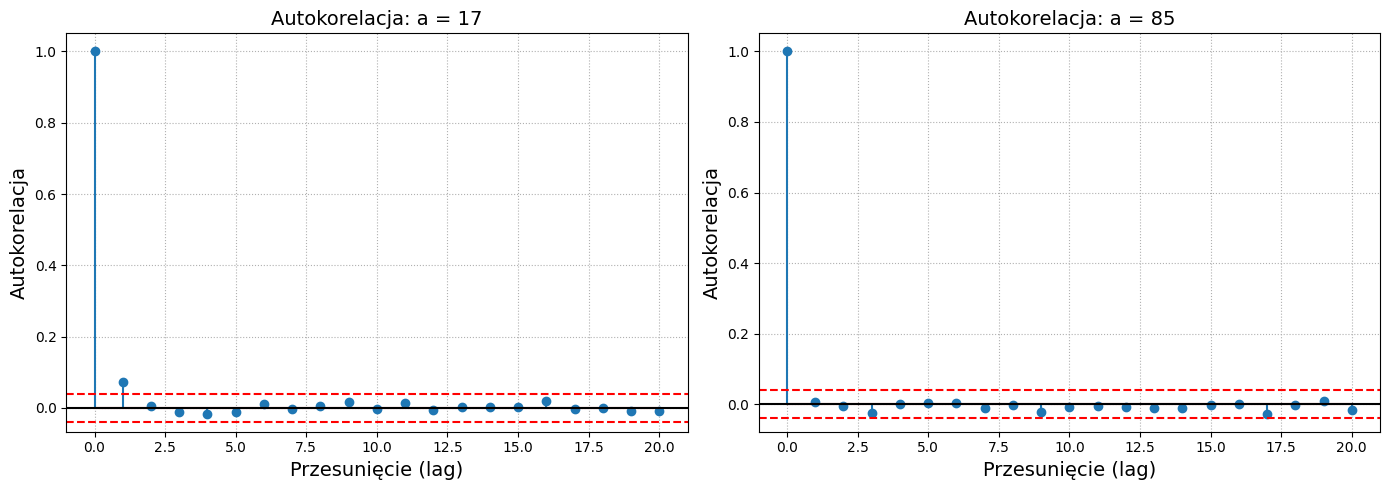

In [38]:
conf_interval = 1.96 / np.sqrt(2500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.stem(range(max_lag + 1), acf_17)
ax1.axhline(y=0, color='k', linestyle='-')
ax1.axhline(y=conf_interval, color='r', linestyle='--')
ax1.axhline(y=-conf_interval, color='r', linestyle='--')
ax1.set_title('Autokorelacja: a = 17', fontsize=14)
ax1.set_xlabel('Przesunięcie (lag)', fontsize=14)
ax1.set_ylabel('Autokorelacja', fontsize=14)
ax1.grid(linestyle=':')

ax2.stem(range(max_lag + 1), acf_85)
ax2.axhline(y=0, color='k', linestyle='-')
ax2.axhline(y=conf_interval, color='r', linestyle='--')
ax2.axhline(y=-conf_interval, color='r', linestyle='--')
ax2.set_title('Autokorelacja: a = 85', fontsize=14)
ax2.set_xlabel('Przesunięcie (lag)', fontsize=14)
ax2.set_ylabel('Autokorelacja', fontsize=14)
ax2.grid(linestyle=':')

plt.tight_layout()
plt.savefig('./plots/autokorelacja_porownanie.pdf', format='pdf')
plt.show()

### Wnioski
Dla generatora z alpha = 17, możemy zauważyć, dla przesunięcia = 1 przebicie górnej granicy przedziału ufności. Jest to dowodem na istnienie korelacji między sąsiadującymi próbkami, zgadza się to również z wnioskami z poprzednich podpunktów.
Z kolei dla generatora z alpha = 85, wartości autokorelacji dla wszystkich badanych opóźnień mieszczą się w czerwonym przedziale ufności. Oznacza to brak wyraźnych korelacji liniowych w tym zakresie.

## Zadanie 2 - Wichmann Hill

### Generator

In [39]:
def wichmann_hill(n, seed_x=1, seed_y=1, seed_z=1):
    x = seed_x
    y = seed_y
    z = seed_z

    for _ in range(n):
        x = (171 * x) % 30269
        y = (172 * y) % 30307
        z = (170 * z) % 30323
        k = (x / 30269.0 + y / 30307.0 + z / 30323.0) % 1.0
        yield k

### Struktura przestrzenna

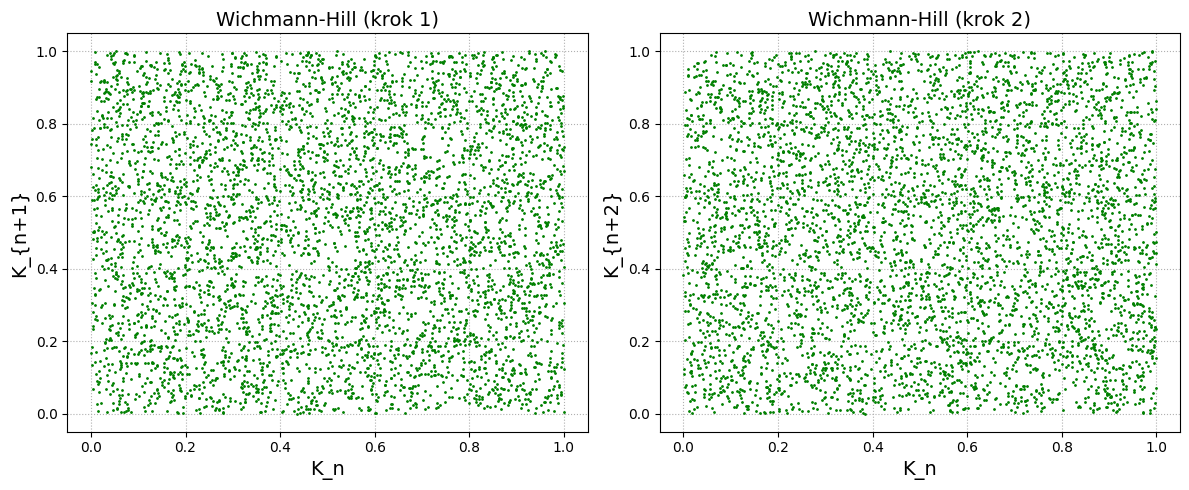

In [40]:
seq_wh = list(wichmann_hill(5000))

with open('./data/wh_step1.txt', 'w') as f:
    for i in range(len(seq_wh) - 1):
        f.write(f"{seq_wh[i]} {seq_wh[i+1]}\n")

with open('./data/wh_step2.txt', 'w') as f:
    for i in range(len(seq_wh) - 2):
        f.write(f"{seq_wh[i]} {seq_wh[i+2]}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x1, y1 = np.loadtxt('./data/wh_step1.txt', unpack=True)
ax1.plot(x1, y1, 'go', markersize=1)
ax1.set_title('Wichmann-Hill (krok 1)', fontsize=14)
ax1.set_xlabel('K_n', fontsize=14)
ax1.set_ylabel('K_{n+1}', fontsize=14)
ax1.grid(linestyle=':')

x2, y2 = np.loadtxt('./data/wh_step2.txt', unpack=True)
ax2.plot(x2, y2, 'go', markersize=1)
ax2.set_title('Wichmann-Hill (krok 2)', fontsize=14)
ax2.set_xlabel('K_n', fontsize=14)
ax2.set_ylabel('K_{n+2}', fontsize=14)
ax2.grid(linestyle=':')

plt.tight_layout()
plt.savefig('./plots/wichmann_hill.pdf', format='pdf')
plt.show()

### Wnioski
W tym eksperymencie wykorzystałem większą liczbę próbek aby powierzchnia była gęściej zaludniona. W przeciwieństwie do poprzedniego generatora, algorytm Wichmanna-Hilla całkowicie eliminuje zjawisko układania się punktów w widoczne, równoległe proste. Wygenerowane wartości tworzą równomierną chmurę, która bardzo dobrze imituje idealny szum losowy i pokrywa całą dostępną przestrzeń bez rozległych, pustych luk.

Co więcej, brak ukrytych korelacji strukturalnych utrzymuje się również przy analizie z krokiem równym 2, gdzie wcześniej badany, pojedynczy generator multiplikatywny całkowicie zawodził. Udowadnia to, że zastosowanie algorytmu złożonego (połączenie kilku prostych generatorów) drastycznie poprawia właściwości statystyczne i skutecznie maskuje liniowe zależności, czyniąc z niego znacznie lepsze i pewniejsze narzędzie do zaawansowanych symulacji.

## Zadanie 3 - Porównanie generatorów

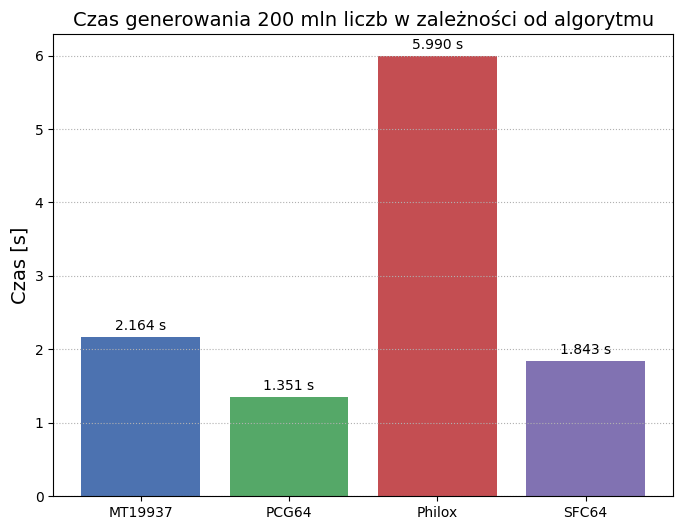

In [43]:
generators = {
    "MT19937": np.random.MT19937(),
    "PCG64": np.random.PCG64(),
    "Philox": np.random.Philox(),
    "SFC64": np.random.SFC64()
}

N = 200_000_000
times = {}

for name, bit_gen in generators.items():
    rng = np.random.Generator(bit_gen)

    start_time = time.perf_counter()
    _ = rng.uniform(0.0, 10.0, N)
    end_time = time.perf_counter()

    times[name] = end_time - start_time

names = list(times.keys())
durations = list(times.values())

plt.figure(figsize=(8, 6))
bars = plt.bar(names, durations, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.bar_label(bars, fmt='%.3f s', padding=3)
plt.title('Czas generowania 200 mln liczb w zależności od algorytmu', fontsize=14)
plt.ylabel('Czas [s]', fontsize=14)
plt.grid(axis='y', linestyle=':')
plt.savefig('wykres_slupkowy_rng.pdf', format='pdf')
plt.show()

### Uwagi
1. W Pythonie/Numpy utworzenie generatora bez podania stałego seeda, wykorzystuje mechanizm fizycznego źródła liczb losowych.
2. Do porównań wykorzystano 4 generatory: MT19937, PCG64, Philox, SFC64. Dostępne w bibliotece Numpy.
3. Jako przedział generowanych liczb przyjęto przedział [0, 10)
4. Czas pomiaru wyznaczono dla ciągów o długości 200 milionów liczb. Taka wielkość próby zagwarantowała, że każdy z generatorów pracował przez co najmniej kilkaset milisekund.
5. Do pomiaru czasu wykorzystano time.perf_counter().

### Wnioski

Najszybszymi generatorami okazały się PCG64 oraz SFC64. Klasyczny Mersenne Twister (MT19937) jest od nich zauważalnie wolniejszy, co tłumaczy, dlaczego zrezygnowano z niego jako domyślnego silnika w nowszych wersjach biblioteki NumPy.